# 多元线性回归：加州房价预测（引入L2正则化惩罚）
~~选择L2正则化（岭回归）的原因：好写~~
## 导入库并设置中文字体（AI给的）

In [11]:
import numpy as np  # 用于科学计算的库，提供数组支持
import pandas as pd  # 用于数据处理的库
import matplotlib.pyplot as plt  # 用于绘图
import seaborn as sns  # 提供更美观的绘图样式
from sklearn.datasets import fetch_california_housing  # 加载California房价数据集
from sklearn.model_selection import train_test_split  # 数据集划分函数
from sklearn.preprocessing import StandardScaler # 数据标准化

import matplotlib
import platform

# 根据操作系统选择中文字体
system = platform.system()
if system == 'Windows':
    font_path = 'SimHei'  # Windows 黑体
elif system == 'Darwin':  # macOS
    font_path = 'PingFang SC'  # macOS 苹方
else:  # Linux
    font_path = 'WenQuanYi Zen Hei'  # Linux 文泉驿

# 设置全局字体
plt.rcParams['font.sans-serif'] = [font_path, 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

## 收集数据

In [12]:
# 一行代码下载并加载数据
california_housing = fetch_california_housing()

# 查看数据基本信息
print(f"数据形状: {california_housing.data.shape}")      # (20640, 8)
print(f"目标变量形状: {california_housing.target.shape}") # (20640,)
print(f"特征名称: {california_housing.feature_names}")
print(f"数据描述:\n{california_housing.DESCR}")

# 将数据集转换为DataFrame并添加列名
df = pd.DataFrame(california_housing.data, columns=california_housing.feature_names)

# 将目标值转为Series对象
target = pd.Series(california_housing.target, name='MedHouseVal')
df['MedHouseVal'] = target # 合并特征和目标变量

数据形状: (20640, 8)
目标变量形状: (20640,)
特征名称: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
数据描述:
.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for Californ

## 数据可视化分析（纯AI，无人工，观察数据用的）

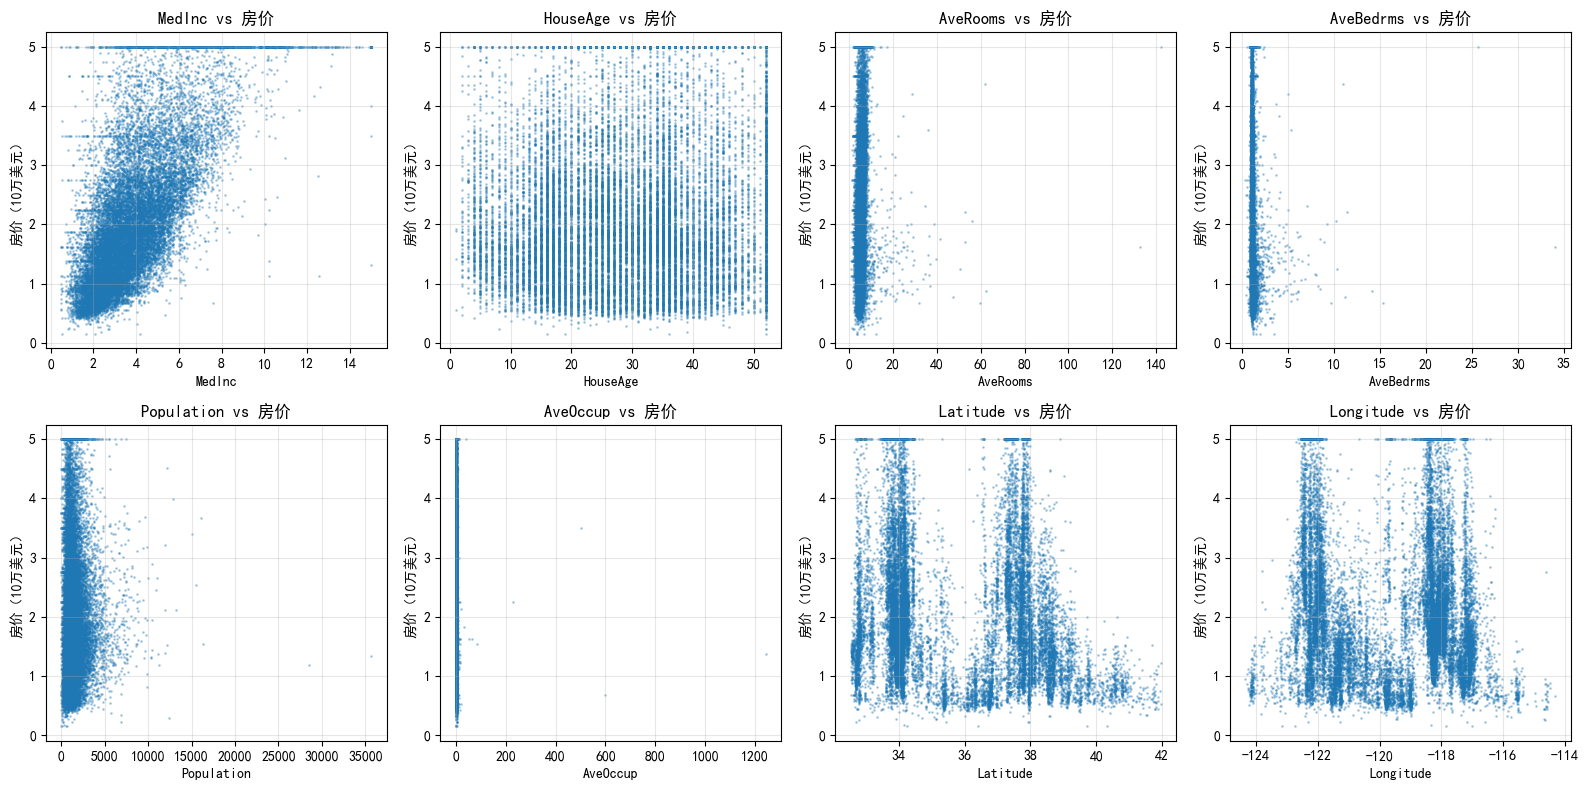

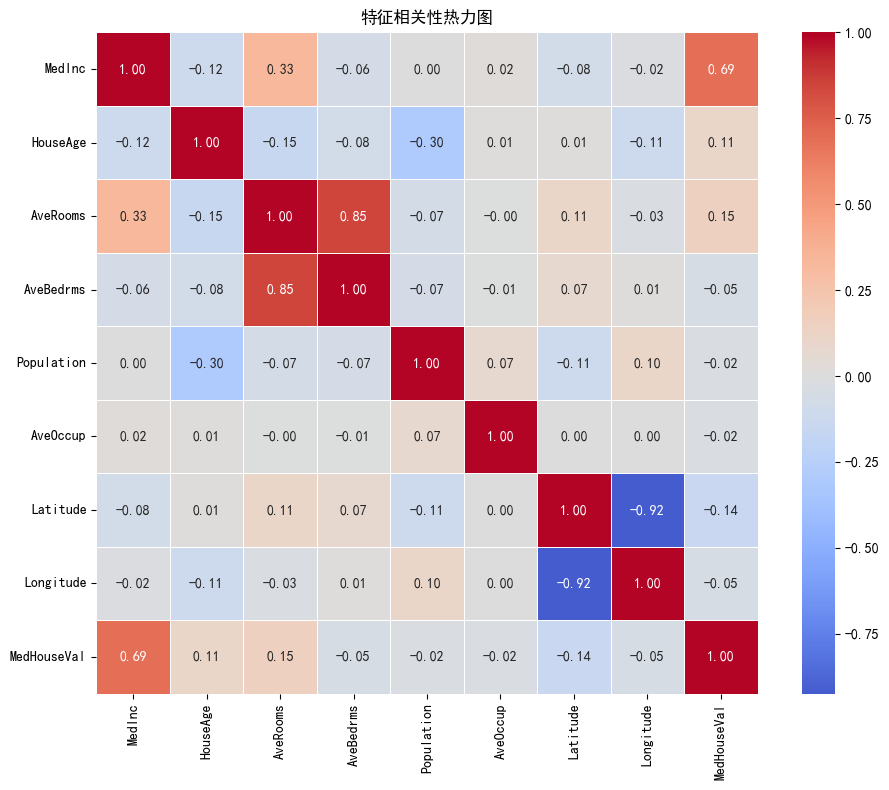

In [13]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

# 绘制每个特征与房价的关系
for i, feature in enumerate(california_housing.feature_names):
    axes[i].scatter(df[feature], df['MedHouseVal'], alpha=0.3, s=1)
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('房价（10万美元）')
    axes[i].set_title(f'{feature} vs 房价')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 相关性热力图
plt.figure(figsize=(10, 8))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, fmt='.2f', linewidths=0.5)
plt.title('特征相关性热力图')
plt.tight_layout()
plt.show()

## 拆分数据集
80%用于训练, 20%用于测试

### 数据标准化
1. 消除量纲影响，让系数可比
2. 加快模型训练速度

In [14]:
# 划分训练集和测试集（80%训练，20%测试）
X_train, X_test, y_train, y_test = train_test_split(
    california_housing.data, california_housing.target, test_size=0.2, random_state=42
)

print(f"\n数据集划分：")
print(f"训练集大小: {X_train.shape[0]}")
print(f"测试集大小: {X_test.shape[0]}")

# 标准化特征（对于线性回归，标准化有助于系数解释和收敛）
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


数据集划分：
训练集大小: 16512
测试集大小: 4128


## 手写多元线性回归类
$使用岭回归 (X^T X + \alpha I)^{-1} X^T y$

In [19]:
class LinearRegression:
    def __init__(self, alpha = 1.0):
        self.weights = None      # 权重系数 w
        self.intercept = None    # 截距项 b
        self.alpha = alpha

    # 训练模型
    def train(self, X, y):
        # 添加一列1作为截距项（这样可以直接用矩阵运算）
        X_b = np.hstack([X, np.ones((X.shape[0], 1))])

        n_features = X_b.shape[1]
        I = np.eye(n_features)
        I[-1, -1] = 0  # 截距项不正则化
        
        self.weights = np.linalg.pinv(X_b.T @ X_b + self.alpha * I) @ X_b.T @ y
        
        self.intercept = self.weights[-1]
        self.weights = self.weights[:-1]
        
        return self

    # 预测结果
    def predict(self, X):
        return X @ self.weights + self.intercept

    # 评价函数
    def score(self, X, y):
        y_pred = self.predict(X)
        ss_res = np.sum((y - y_pred) ** 2)
        ss_tot = np.sum((y - np.mean(y)) ** 2)
        r2 = 1 - (ss_res / ss_tot)
        return r2

model = LinearRegression()
model.train(X_train_scaled, y_train)
params = {"weights" : model.weights, 
          "intercept" : model.intercept}

print(f"\n模型参数：")
for name, weight in zip(california_housing.feature_names, params['weights']):
    print(f"  {name:15s}: {weight:10.6f}")
print(f"  {'截距':15s}: {params['intercept']:10.6f}")

# 评估
print (f"训练集R2 : {model.score (X_train_scaled, y_train)}")
print (f"训练集R2 : {model.score (X_test_scaled, y_test)}")


模型参数：
  MedInc         :   0.854327
  HouseAge       :   0.122624
  AveRooms       :  -0.294210
  AveBedrms      :   0.339008
  Population     :  -0.002282
  AveOccup       :  -0.040833
  Latitude       :  -0.896168
  Longitude      :  -0.869071
  截距             :   2.071947
训练集R2 : 0.612551121863456
训练集R2 : 0.5758157428913686


$由于预设的 \alpha 是瞎填的，所以似乎跟加入正则惩罚前差别不大$